In [1]:
# %pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#생각 : 과연 자연의 환경적인 부분은 자전거를 대여하는 횟수에 영향을 끼칠까?

bike_df = pd.read_csv('./datasets/Seoul-bicycle-rental-dataset.csv')
bike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   str    
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(蚓)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(蚓)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   str    
 12  Holiday                   8760 non-null   str    
 13  Functioning Day           8760 non-null   str    
dtypes: float64(6), int6

In [3]:
# 각 컬럼별 결측치(NaN) 개수를 확인
bike_df.isna().sum()

Date                        0
Rented Bike Count           0
Hour                        0
Temperature(蚓)              0
Humidity(%)                 0
Wind speed (m/s)            0
Visibility (10m)            0
Dew point temperature(蚓)    0
Solar Radiation (MJ/m2)     0
Rainfall(mm)                0
Snowfall (cm)               0
Seasons                     0
Holiday                     0
Functioning Day             0
dtype: int64

In [4]:
# 수치형 컬럼의 기술통계량 확인 (평균, 표준편차, 최소, 최대, 사분위수 등)
bike_df.describe()

,Rented Bike Count,Hour,Temperature(蚓),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(蚓),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [5]:
bike_df.columns = ['Date', 'RentedBikeCount', 'Hour', 'Temperature', 'Humidity',
       'WindSpeed', 'Visibility', 'DewPointTemperature',
       'SolarRadiation', 'Rainfall', 'Snowfall', 'Seasons',
       'Holiday', 'FunctioningDay']
plt.rcParams['font.family'] = 'Malgun Gothic'

In [46]:
bike_df.duplicated().sum()

np.int64(0)

In [6]:
bike_df.head()

,Date,RentedBikeCount,Hour,Temperature,Humidity,WindSpeed,Visibility,DewPointTemperature,SolarRadiation,Rainfall,Snowfall,Seasons,Holiday,FunctioningDay
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


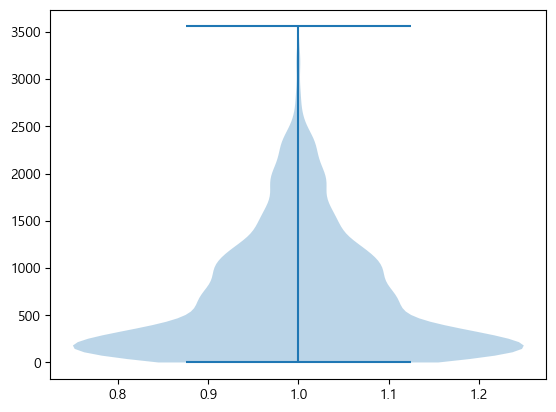

In [7]:
# 데이터의 분포 형태(어디에 데이터가 많이 몰려있는지)를 직관적으로 보여줌
plt.violinplot(bike_df.RentedBikeCount)
plt.show()

# sns.violinplot(data=bike_df, x='RentedBikeCount', y='Temperature', hue='RentedBikeCount')
# plt.show()

C:\Users\dlwns\anaconda3\envs\data-analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


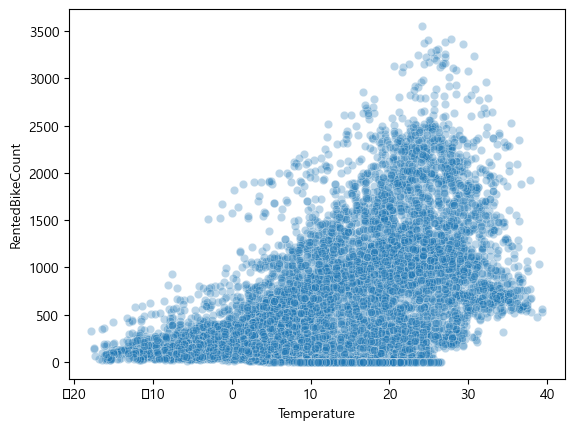

In [8]:
# x='Temperature': x축에 온도 배치
# y='RentedBikeCount': y축에 자전거 대여 수 배치
# alpha=0.3: 각 데이터 포인트(점)의 투명도를 설정 (0.0 ~ 1.0 범위)
sns.scatterplot(x='Temperature', y='RentedBikeCount', data=bike_df, alpha=0.3)
plt.show()

<Axes: xlabel='WindSpeed', ylabel='RentedBikeCount'>

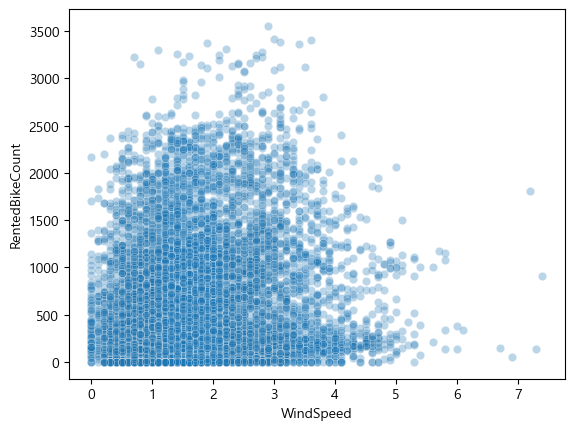

In [9]:
# 풍속이 자전거 대여량에 미치는 영향을 확인
sns.scatterplot(x='WindSpeed', y='RentedBikeCount', data=bike_df, alpha=0.3)

<BarContainer object of 8760 artists>

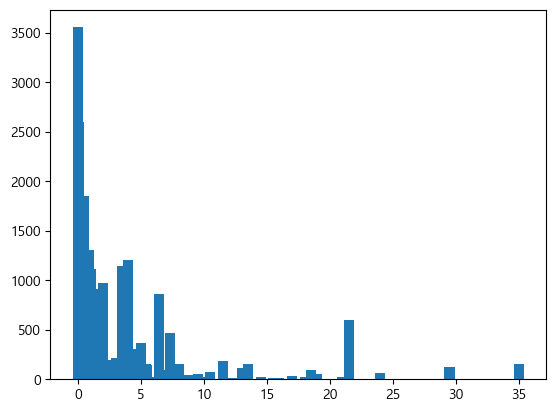

In [10]:
# 강수량(Rainfall)별 자전거 대여량을 막대로 표시
plt.bar(data=bike_df, x='Rainfall', height='RentedBikeCount')

C:\Users\dlwns\anaconda3\envs\data-analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


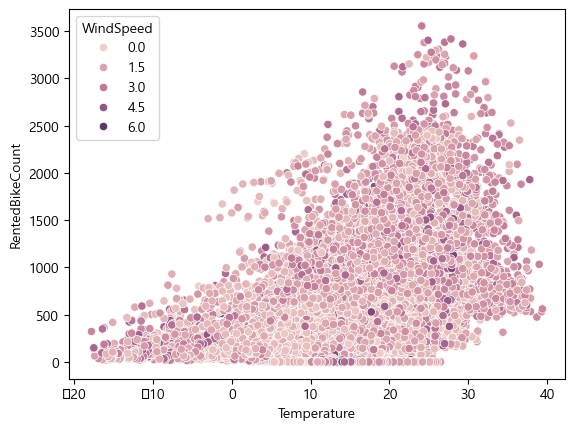

In [12]:
# hue='WindSpeed': 세 번째 변수(풍속)를 색상(hue)으로 매핑
sns.scatterplot(data=bike_df, x='Temperature', y='RentedBikeCount', hue='WindSpeed')
plt.show()

In [13]:
# dayfirst=True: 날짜 형식이 '일/월/년'인 경우 올바르게 파싱
bike_df.Date = pd.to_datetime(bike_df.Date, dayfirst=True)
bike_df

,Date,RentedBikeCount,Hour,Temperature,Humidity,WindSpeed,Visibility,DewPointTemperature,SolarRadiation,Rainfall,Snowfall,Seasons,Holiday,FunctioningDay
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


C:\Users\dlwns\AppData\Local\Temp\ipykernel_5388\3692111727.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  line.set_xticklabels(line.get_xticklabels(), rotation=90)


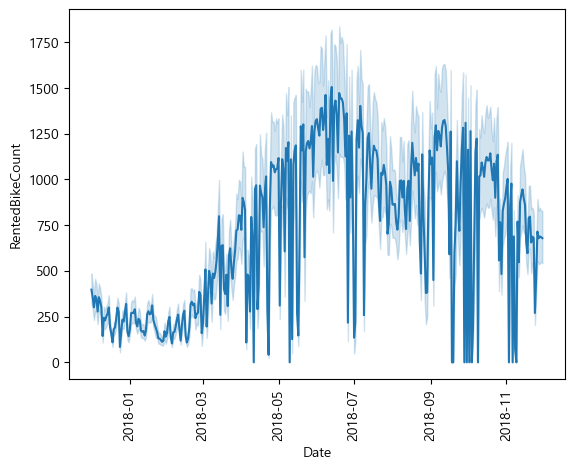

In [14]:
# x축 라벨을 90도 회전시켜 날짜가 겹치지 않게 표시
line = sns.lineplot(data=bike_df, x='Date', y='RentedBikeCount')
line.set_xticklabels(line.get_xticklabels(), rotation=90)
plt.show()

In [15]:
# dt.year/month/day: datetime 타입에서 연/월/일 정보를 추출하는 접근자
bike_df['year'] = bike_df['Date'].dt.year
bike_df['month'] = bike_df['Date'].dt.month
bike_df['day'] = bike_df['Date'].dt.day
bike_df.head()

,Date,RentedBikeCount,Hour,Temperature,Humidity,WindSpeed,Visibility,DewPointTemperature,SolarRadiation,Rainfall,Snowfall,Seasons,Holiday,FunctioningDay,year,month,day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1


In [16]:
# 조건 필터링(year==2017) -> 월별 그룹화 -> 평균 계산
bike_df[bike_df['year'] == 2017].groupby('month')['RentedBikeCount'].mean()

month
12    249.099462
Name: RentedBikeCount, dtype: float64

In [17]:
# 2017년과 비교하여 연도별 대여 패턴 변화를 확인
bike_df[bike_df['year'] == 2018].groupby('month')['RentedBikeCount'].mean()

month
1      201.620968
2      225.941964
3      511.551075
4      728.093056
5      950.387097
6     1245.676389
7      987.177419
8      876.192204
9      935.572222
10     874.563172
11     646.826389
Name: RentedBikeCount, dtype: float64

In [18]:
# pd.cut(): 연속형 변수를 구간별로 나누어 범주형으로 변환
# bins: 구간 경계값 [0~5: Dawn, 6~11: Morning, 12~17: Afternoon, 18~23: Evening]
# labels: 각 구간에 부여할 이름
# include_lowest=True: 최소값(0)을 첫 번째 구간에 포함
bike_df['TimeOfDay'] = pd.cut(bike_df['Hour'],
                            bins=[0, 5, 11, 17, 23],
                            labels=['Dawn', 'Morning', 'Afternoon', 'Evening'],)

<Axes: xlabel='Seasons', ylabel='RentedBikeCount'>

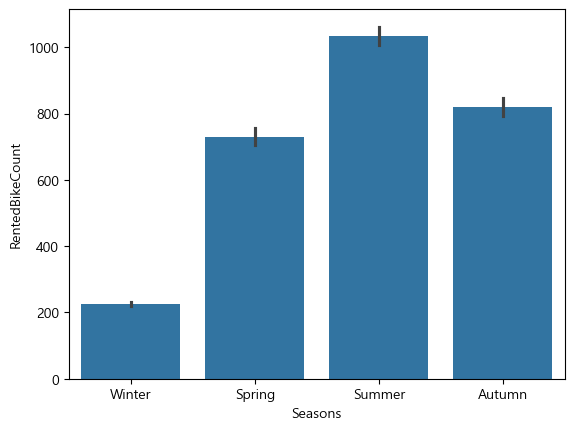

In [19]:
# barplot: 범주별 평균값과 신뢰구간(검은 선)을 함께 표시
sns.barplot(x='Seasons', y='RentedBikeCount', data=bike_df)

In [20]:
# value_counts(): 각 고유값의 출현 빈도를 계산
bike_df['FunctioningDay'].value_counts()

FunctioningDay
Yes    8465
No      295
Name: count, dtype: int64

In [21]:
# 각 계절에 데이터가 얼마나 있는지 확인 (데이터 균형 파악)
bike_df['Seasons'].value_counts()

Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

In [22]:
# 현재 데이터프레임의 전체 컬럼명 목록 확인
bike_df.columns

Index(['Date', 'RentedBikeCount', 'Hour', 'Temperature', 'Humidity',
       'WindSpeed', 'Visibility', 'DewPointTemperature', 'SolarRadiation',
       'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'FunctioningDay', 'year',
       'month', 'day', 'TimeOfDay'],
      dtype='str')

C:\Users\dlwns\AppData\Local\Temp\ipykernel_5388\3773703942.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  line.set_xticklabels(line.get_xticklabels(), rotation=90)


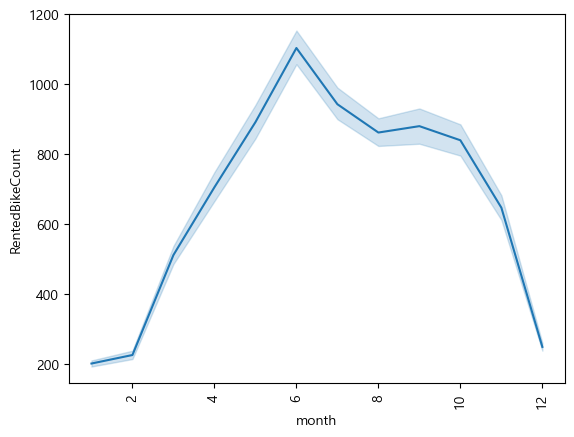

In [43]:
# 대여량에 따른 월의 변화 추이를 선 그래프로 시각화
line = sns.lineplot(data=bike_df, x='month', y='RentedBikeCount')
line.set_xticklabels(line.get_xticklabels(), rotation=90)
plt.show()

In [24]:
# 자전거 대여소가 정상 운영된 날의 데이터만 확인
bike_df[bike_df['FunctioningDay'] == 'Yes']

,Date,RentedBikeCount,Hour,Temperature,Humidity,WindSpeed,Visibility,DewPointTemperature,SolarRadiation,Rainfall,Snowfall,Seasons,Holiday,FunctioningDay,year,month,day,TimeOfDay
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,NaN
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening


In [25]:
# 대여소가 운영되지 않은 날의 데이터 확인 (대여량이 0일 가능성 높음)
bike_df[bike_df['FunctioningDay'] == 'No']

,Date,RentedBikeCount,Hour,Temperature,Humidity,WindSpeed,Visibility,DewPointTemperature,SolarRadiation,Rainfall,Snowfall,Seasons,Holiday,FunctioningDay,year,month,day,TimeOfDay
3144,2018-04-11,0,0,14.4,82,4.6,1041,11.3,0.0,0.0,0.0,Spring,No Holiday,No,2018,4,11,NaN
3145,2018-04-11,0,1,13.6,81,3.6,886,10.3,0.0,0.0,0.0,Spring,No Holiday,No,2018,4,11,Dawn
3146,2018-04-11,0,2,12.7,80,3.9,885,9.3,0.0,0.0,0.0,Spring,No Holiday,No,2018,4,11,Dawn
3147,2018-04-11,0,3,11.6,81,3.1,687,8.4,0.0,0.0,0.0,Spring,No Holiday,No,2018,4,11,Dawn
3148,2018-04-11,0,4,10.2,83,3.5,554,7.4,0.0,0.0,0.0,Spring,No Holiday,No,2018,4,11,Dawn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8251,2018-11-09,0,19,11.9,71,2.7,589,6.7,0.0,0.0,0.0,Autumn,No Holiday,No,2018,11,9,Evening
8252,2018-11-09,0,20,11.9,72,2.5,526,7.0,0.0,0.0,0.0,Autumn,No Holiday,No,2018,11,9,Evening
8253,2018-11-09,0,21,11.4,74,1.9,498,6.9,0.0,0.0,0.0,Autumn,No Holiday,No,2018,11,9,Evening
8254,2018-11-09,0,22,11.2,75,1.7,478,6.9,0.0,0.0,0.0,Autumn,No Holiday,No,2018,11,9,Evening


In [26]:
# 이미 year, month, day로 분리했으므로 원본 Date 컬럼은 불필요
bike_df = bike_df.drop('Date', axis=1)
bike_df.head()

,RentedBikeCount,Hour,Temperature,Humidity,WindSpeed,Visibility,DewPointTemperature,SolarRadiation,Rainfall,Snowfall,Seasons,Holiday,FunctioningDay,year,month,day,TimeOfDay
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,NaN
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn


In [29]:

from scipy.stats import iqr

rbc1 = np.percentile(bike_df.RentedBikeCount, 25) 
rbc2 = np.percentile(bike_df.RentedBikeCount, 75)

iqr_value = iqr(bike_df.RentedBikeCount)

lower_bound = max(0, rbc1 - 1.5 * iqr_value)  
upper_bound = rbc2 + 1.5 * iqr_value            
print(f'이상치 범위: {lower_bound} ~ {upper_bound}')

IQR: 874.25
이상치 범위: 0 ~ 2376.625


In [30]:
print(rbc1)
print(iqr_value)

191.0
874.25


In [31]:
condition1 = bike_df.RentedBikeCount >= lower_bound
condition2 = bike_df.RentedBikeCount <= upper_bound
condition = condition1 & condition2

bike_df = bike_df[condition]
bike_df

,RentedBikeCount,Hour,Temperature,Humidity,WindSpeed,Visibility,DewPointTemperature,SolarRadiation,Rainfall,Snowfall,Seasons,Holiday,FunctioningDay,year,month,day,TimeOfDay
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,NaN
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8756,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8757,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8758,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening


In [32]:
# drop=True: 기존 인덱스를 컬럼으로 추가하지 않고 버림
# inplace=True: 원본 데이터프레임을 직접 수정 (새 변수에 할당하지 않아도 됨)
bike_df.reset_index(drop=True, inplace=True)
bike_df

,RentedBikeCount,Hour,Temperature,Humidity,WindSpeed,Visibility,DewPointTemperature,SolarRadiation,Rainfall,Snowfall,Seasons,Holiday,FunctioningDay,year,month,day,TimeOfDay
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,NaN
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8597,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8598,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8599,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8600,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening


In [33]:
# .T: 전치(Transpose)하여 컬럼이 행으로 표시되어 가독성이 좋아짐
bike_df.describe().T

,count,mean,std,min,25%,50%,75%,max
RentedBikeCount,8602.0,667.971635,589.552620,0.0,188.0,485.00,1030.75,2375.00
Hour,8602.0,11.377122,6.920938,0.0,5.0,11.00,17.00,23.00
Temperature,8602.0,12.674890,11.937911,-17.8,3.2,13.30,22.20,39.40
Humidity,8602.0,58.372937,20.455133,0.0,42.0,57.00,74.00,98.00
WindSpeed,8602.0,1.716124,1.038349,0.0,0.9,1.50,2.30,7.40
Visibility,8602.0,1431.978958,610.175009,27.0,929.0,1689.50,2000.00,2000.00
DewPointTemperature,8602.0,3.916624,13.102464,-30.6,-4.9,4.80,14.70,27.20
SolarRadiation,8602.0,0.568715,0.874273,0.0,0.0,0.01,0.93,3.52
Rainfall,8602.0,0.151407,1.138328,0.0,0.0,0.00,0.00,35.00
Snowfall,8602.0,0.076447,0.440620,0.0,0.0,0.00,0.00,8.80


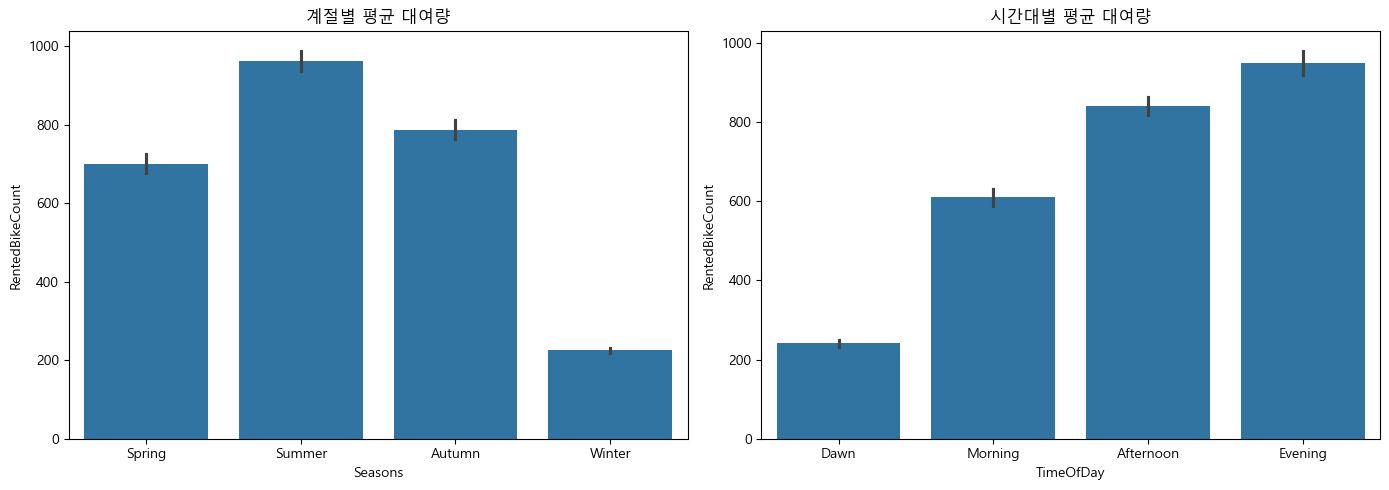

In [44]:
# fig, axes = plt.subplots(1, 2): 1행 2열의 서브플롯 생성 (좌: 계절, 우: 시간대)
# figsize=(14, 5): 전체 그림 크기를 가로 14, 세로 5 인치로 설정
# order: 막대가 표시되는 순서를 지정
# ax=axes[0]: 첫 번째 서브플롯에 그래프 배치
# plt.tight_layout(): 서브플롯 간 간격을 자동 조정하여 겹침 방지
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=bike_df, x="Seasons", y="RentedBikeCount",
            order=["Spring", "Summer", "Autumn", "Winter"], ax=axes[0])
axes[0].set_title("계절별 평균 대여량")

sns.barplot(data=bike_df, x="TimeOfDay", y="RentedBikeCount",
            order=["Dawn", "Morning", "Afternoon", "Evening"], ax=axes[1])
axes[1].set_title("시간대별 평균 대여량")

plt.tight_layout()
plt.show()

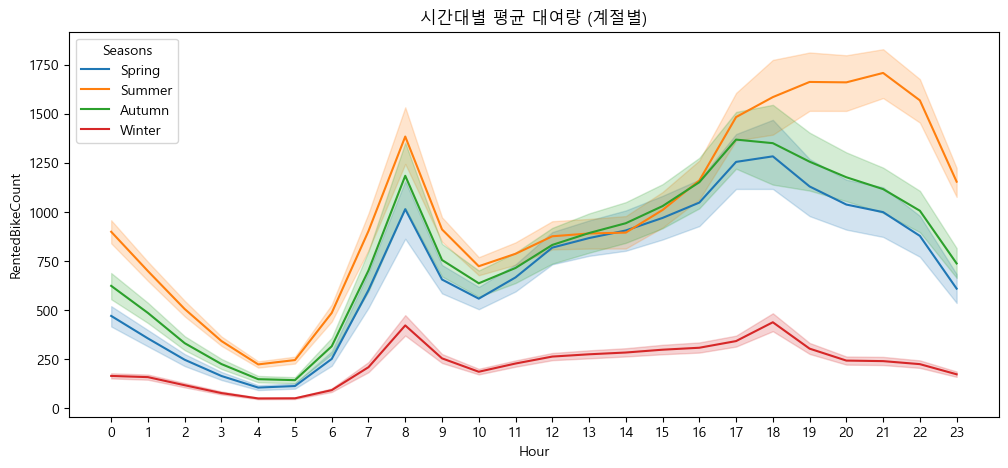

In [35]:
# lineplot: 시간(Hour)에 따른 대여량 변화를 선으로 표시
plt.figure(figsize=(12, 5))
sns.lineplot(data=bike_df, x="Hour", y="RentedBikeCount", hue="Seasons",
             hue_order=["Spring", "Summer", "Autumn", "Winter"])
plt.title("시간대별 평균 대여량 (계절별)")
plt.xticks(range(0, 24))
plt.show()

## 분석 코드

In [36]:
# corr(): 모든 수치형 컬럼 간 상관관계를 계산
corr = bike_df[["RentedBikeCount", "Temperature", "Humidity", "WindSpeed",
                "Visibility", "DewPointTemperature", "SolarRadiation",
                "Rainfall", "Snowfall", "Hour"]].corr()

corr["RentedBikeCount"].drop("RentedBikeCount").sort_values(ascending=False)

Temperature            0.539483
Hour                   0.396070
DewPointTemperature    0.379862
SolarRadiation         0.286884
Visibility             0.193498
WindSpeed              0.104367
Rainfall              -0.127669
Snowfall              -0.145819
Humidity              -0.196393
Name: RentedBikeCount, dtype: float64

In [37]:
# groupby -> mean -> sort_values: 계절별로 그룹화 후 평균 계산 후 정렬
bike_df.groupby("Seasons")["RentedBikeCount"].mean().sort_values(ascending=False)

Seasons
Summer    963.923549
Autumn    787.983240
Spring    700.497011
Winter    225.541204
Name: RentedBikeCount, dtype: float64

In [38]:
# ===== 3. 시간대별 평균 대여량 =====
# observed=False: pd.cut으로 만든 범주형에서 데이터가 없는 구간도 표시
bike_df.groupby("TimeOfDay", observed=False)["RentedBikeCount"].mean()

TimeOfDay
Dawn         240.563836
Morning      610.648673
Afternoon    840.240477
Evening      949.422570
Name: RentedBikeCount, dtype: float64

In [39]:
# idxmax(): 최대값을 가진 인덱스(시간) 반환
# idxmin(): 최소값을 가진 인덱스(시간) 반환
hourly = bike_df.groupby("Hour")["RentedBikeCount"].mean()
print(f"최고: {hourly.idxmax()}시 (평균 {hourly.max():.1f}대)")
print(f"최저: {hourly.idxmin()}시 (평균 {hourly.min():.1f}대)")

최고: 17시 (평균 1109.2대)
최저: 4시 (평균 132.6대)


In [45]:
# 공휴일(Holiday)과 비공휴일(No Holiday)의 평균 대여량 차이를 비교
holiday_mean = bike_df.groupby("Holiday")["RentedBikeCount"].mean()
print(holiday_mean)


Holiday
Holiday       495.348028
No Holiday    677.077102
Name: RentedBikeCount, dtype: float64


In [41]:
# pd.cut(bins=5): 온도 범위를 5개 동일 간격 구간으로 나눔
# 어떤 온도 범위에서 자전거 대여가 가장 활발한지 확인
bike_df["TempBin"] = pd.cut(bike_df["Temperature"], bins=5)
bike_df.groupby("TempBin", observed=False)["RentedBikeCount"].mean()

TempBin
(-17.857, -6.36]     164.814745
(-6.36, 5.08]        278.710407
(5.08, 16.52]        606.994626
(16.52, 27.96]       964.574946
(27.96, 39.4]       1081.449594
Name: RentedBikeCount, dtype: float64

In [42]:
# 가장 대조적인 두 계절의 대여량을 비교하여 계절 영향도를 수치화
# 여름/겨울 비율로 계절 간 차이가 몇 배인지 확인
summer = bike_df[bike_df.Seasons == "Summer"]["RentedBikeCount"].mean()
winter = bike_df[bike_df.Seasons == "Winter"]["RentedBikeCount"].mean()
print(f"여름: {summer:.1f}대")
print(f"겨울: {winter:.1f}대")
print(f"여름/겨울 = {summer/winter:.1f}배")

여름: 963.9대
겨울: 225.5대
여름/겨울 = 4.3배


## 서울시 공공자전거 대여 데이터 분석 결과

### 1. 데이터 개요
- 분석 기간: 2017년 12월 ~ 2018년 11월 (약 1년)
- 이상치 제거 후 총 8,602건의 시간별 대여 데이터를 분석하였다.
- IQR 기법을 사용하여 정상치 범위(0 ~ 2,376대)를 벗어나는 158건의 이상치를 제거하였다.

### 2. 대여량에 영향을 미치는 주요 변수 (상관관계 분석)
| 변수 | 상관계수 | 해석 |
|------|----------|------|
| 기온(Temperature) | **+0.539** | 가장 강한 양의 상관관계. 기온이 높을수록 대여량 증가 |
| 시간(Hour) | +0.396 | 하루 중 늦은 시간대일수록 대여량 증가 경향 |
| 이슬점 온도(DewPointTemperature) | +0.380 | 기온과 유사한 방향으로 영향 |
| 일사량(SolarRadiation) | +0.287 | 햇볕이 강할수록 대여량 증가 |
| 습도(Humidity) | **-0.196** | 습도가 높을수록 대여량 감소 |
| 적설량(Snowfall) | -0.146 | 눈이 오면 대여량 감소 |
| 강수량(Rainfall) | -0.128 | 비가 오면 대여량 감소 |

**핵심 발견**: 기온이 대여량을 결정짓는 가장 중요한 요인이며, 비·눈·습도 등 불쾌한 기상 조건은 대여량을 감소시킨다.

### 3. 계절별 분석
| 계절 | 평균 대여량 |
|------|------------|
| 여름(Summer) | **963.9대** |
| 가을(Autumn) | 788.0대 |
| 봄(Spring) | 700.5대 |
| 겨울(Winter) | **225.5대** |

여름 대여량이 겨울의 약 **4.3배**에 달한다. 기온과의 높은 상관관계(+0.539)가 계절별 차이의 주요 원인으로 보인다.

### 4. 시간대별 분석
| 시간대 | 평균 대여량 |
|--------|------------|
| 저녁(Evening, 18~23시) | **949.4대** |
| 오후(Afternoon, 12~17시) | 840.2대 |
| 오전(Morning, 6~11시) | 610.6대 |
| 새벽(Dawn, 0~5시) | 290.7대 |

- **피크 시간**: 오후 5시(17시)에 평균 1,109.2대로 최대
- **최저 시간**: 새벽 4시에 평균 132.6대로 최소
- 출퇴근 시간대(오전 8시, 오후 5~6시)에 뚜렷한 피크가 나타나며, 이는 자전거가 **통근 수단**으로 활용되고 있음을 시사한다.

### 5. 휴일 vs 평일
| 구분 | 평균 대여량 |
|------|------------|
| 평일(No Holiday) | **677.1대** |
| 휴일(Holiday) | 495.3대 |

평일 대여량이 휴일보다 약 **36.7% 높다**. 이는 출퇴근 통근 수요가 전체 대여량의 상당 부분을 차지한다는 점을 뒷받침한다.

### 6. 온도 구간별 분석
| 온도 구간 | 평균 대여량 |
|-----------|------------|
| -17.8 ~ -6.4°C | 164.8대 |
| -6.4 ~ 5.1°C | 278.7대 |
| 5.1 ~ 16.5°C | 607.0대 |
| 16.5 ~ 28.0°C | 964.6대 |
| 28.0 ~ 39.4°C | **1,081.4대** |

기온이 올라갈수록 대여량이 거의 선형적으로 증가한다. 28°C 이상의 고온에서도 대여량이 줄지 않고 오히려 가장 높은 것이 특징이다.

### 7. 종합 결론
1. **기온이 가장 핵심적인 영향 요인**이다. 여름철 고온일수록 대여량이 크게 증가하며, 겨울에는 4분의 1 수준으로 급감한다.
2. 공공자전거는 **출퇴근 통근 목적**으로 주로 이용되고 있다. 평일 > 휴일, 오후 5시 피크 패턴이 이를 증명한다.
3. 비, 눈, 높은 습도 등 **악천후는 대여량을 감소**시키지만, 기온에 비해 영향력은 상대적으로 작다.
4. 운영 관점에서 **여름 저녁 시간대**에 자전거 배치를 집중하고, **겨울 새벽**에는 운영 효율화를 고려할 필요가 있다.